
| 项目 | 内容 |
|------|------|
| **标题** | t-SNE 降维与可视化 |
| **作者** | 邓涵丹 |
| **周次** | Week 3 |
| **分类** | 机器学习 / 无监督学习 / 降维 |
| **学习目标** | 1. 理解 t-SNE 的核心原理与数学推导<br>2. 掌握 t-SNE 与 PCA 的区别与适用场景<br>3. 能够使用 scikit-learn 实现 t-SNE 降维与可视化<br>4. 学会调参（perplexity、learning_rate 等）并解读结果 |
# t-SNE 降维与可视化

## 1. 背景

### 1.1 为什么需要 t-SNE？
在机器学习和数据分析中，高维数据无处不在（图像、文本向量、基因表达数据等）。人类只能直观理解二维或三维空间，因此**降维可视化**成为数据分析的重要工具。

传统的线性降维方法如 **PCA（主成分分析）** 通过保留最大方差来降维，但**无法很好地保留复杂的非线性流形结构**。例如在 MNIST 手写数字数据集中，PCA 往往将不同类别的数字混杂在一起，难以区分。

**t-SNE（t-Distributed Stochastic Neighbor Embedding）** 由 Laurens van der Maaten 和 Geoffrey Hinton 于 2008 年提出，是一种**非线性降维算法**，专门用于将高维数据映射到 2D 或 3D 空间进行可视化，能够极好地展现数据的聚类结构。

### 1.2 t-SNE 与 PCA 的核心区别

| 对比维度 | PCA | t-SNE |
|----------|-----|-------|
| 方法类型 | 线性降维 | 非线性降维 |
| 核心目标 | 最大化方差 | 保留局部相似性 |
| 全局 vs 局部 | 保留全局结构 | 强调局部结构 |
| 速度 | 快速 | 较慢（O(N²)） |
| 结果解释 | 主成分有明确线性含义 | 专用于可视化，无物理含义 |

> **核心洞察**：t-SNE 不再关注点与点之间的绝对欧氏距离，而是**基于概率定义相似性**，让高维和低维空间中的概率分布尽可能对齐。

In [1]:
# Cell 3: 导入所有依赖库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（解决Mac/Win显示问题，可选）
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac
# plt.rcParams['font.sans-serif'] = ['SimHei']           # Win

print("所有依赖库导入成功！")
print(f"NumPy version: {np.__version__}")

所有依赖库导入成功！
NumPy version: 2.3.2


## 2. 最小示例（Minimum Working Example）

我们先加载 MNIST 数据集（取前 3000 个样本以加速演示），进行标准化，使用 PCA 预处理降速，最后用 t-SNE 映射到 2 维并可视化。

In [2]:
# Cell 5: 加载数据与预处理
print("1. 正在加载 MNIST 数据...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X = mnist.data.values[:3000]   # 取前 3000 个样本
y = mnist.target.values[:3000].astype(int)
print(f"   原始数据形状: {X.shape}")

# 标准化（t-SNE 对尺度敏感）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("   数据标准化完成。")

1. 正在加载 MNIST 数据...
   原始数据形状: (3000, 784)
   数据标准化完成。


In [4]:
# Cell 6: PCA 预处理 + t-SNE 降维
# 先用 PCA 降到 50 维（保留主要信息，同时大幅加速 t-SNE）
print("2. PCA 预处理中...")
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"   PCA 后数据形状: {X_pca.shape}，累积方差比: {pca.explained_variance_ratio_.sum():.4f}")

# t-SNE 降维到 2 维
print("3. t-SNE 降维中（耗时约 20-40 秒，请耐心等待）...")
start_time = time.time()
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    max_iter=1000,    # ✅ 新版参数名
    verbose=0
)
X_tsne = tsne.fit_transform(X_pca)
print(f"   t-SNE 耗时: {time.time() - start_time:.2f} 秒")
print(f"   降维结果形状: {X_tsne.shape}")

2. PCA 预处理中...
   PCA 后数据形状: (3000, 50)，累积方差比: 0.6304
3. t-SNE 降维中（耗时约 20-40 秒，请耐心等待）...
   t-SNE 耗时: 4.51 秒
   降维结果形状: (3000, 2)


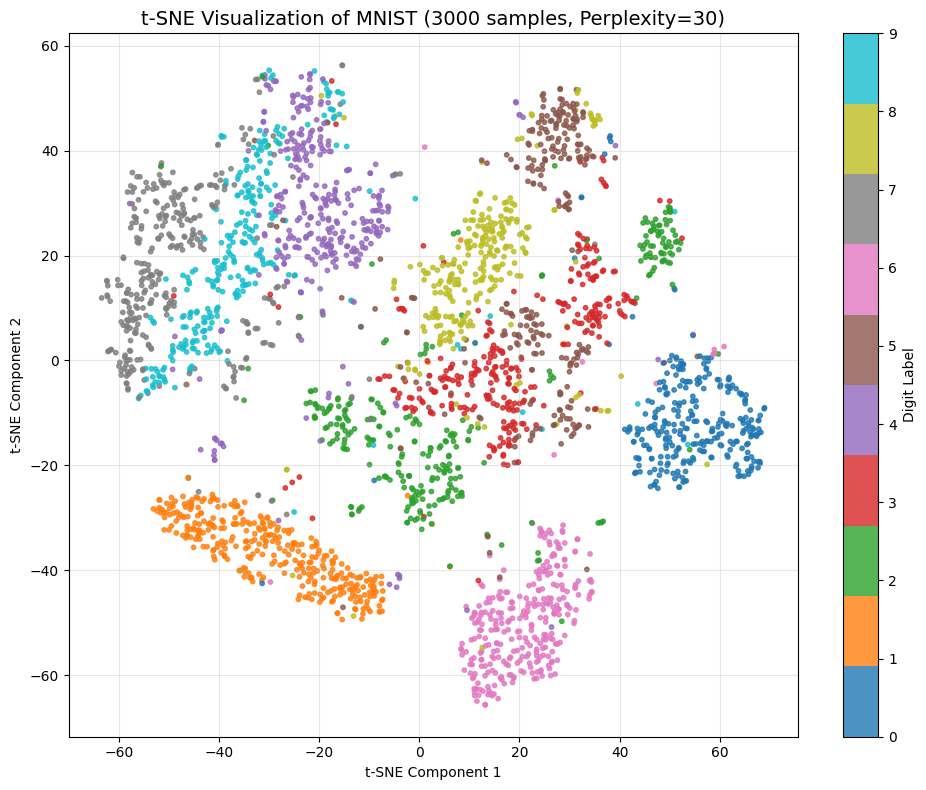

In [5]:
# Cell 7: 可视化 t-SNE 结果
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=10, alpha=0.8)
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.title('t-SNE Visualization of MNIST (3000 samples, Perplexity=30)', fontsize=14)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 关键原理解释

### 3.1 SNE 的基本思想
SNE（Stochastic Neighbor Embedding）是 t-SNE 的前身，核心包含两步：
1. **高维空间**：将欧氏距离转化为**条件概率** $p_{j|i}$，表示点 $x_i$ 以多大概率选择 $x_j$ 作为其邻居（基于高斯核）。
$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$
2. **低维空间**：同样构建概率分布 $q_{j|i}$，目标是让 $Q$ 分布尽可能接近 $P$ 分布。

### 3.2 困惑度（Perplexity）
困惑度控制每个点高斯核的带宽 $\sigma_i$，可以理解为**有效近邻数量**。通常取值在 5-50 之间：
$$\text{Perplexity}(P_i) = 2^{H(P_i)}$$
- 较小值（如 5）关注局部细节，可能产生许多小簇；
- 较大值（如 50）关注全局结构，但可能模糊局部边界。

### 3.3 目标函数：KL 散度
优化目标是最小化高维分布 $P$ 和低维分布 $Q$ 之间的 KL 散度：
$$C = \sum_i KL(P_i \| Q_i) = \sum_i \sum_j p_{j|i} \log \frac{p_{j|i}}{q_{j|i}}$$
**重要性质**（由 KL 不对称性导致）：
- 高维近 → 低维远：**惩罚极大**（局部结构被破坏）；
- 高维远 → 低维近：**惩罚较小**。
这就是 t-SNE 极度**保护局部近邻关系**的根本原因。

### 3.4 拥挤问题与 t 分布
高维空间容积太大，导致点之间等距（“拥挤”），低维空间无法容纳。解决方案：低维空间使用**自由度为 1 的学生 t 分布**（即柯西分布）。t 分布具有**长尾**特性，允许低维空间中距离较远的点依然保持较高的相似度，从而缓解拥挤。
$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|y_k - y_l\|^2)^{-1}}$$

### 3.5 重要注意事项
1. t-SNE 只有 `fit_transform`，**没有** `fit`，不能用于映射新数据；
2. 结果对随机种子敏感，建议固定 `random_state` 保证复现；
3. 计算复杂度 $O(N^2)$，大样本需先抽样；
4. **强烈建议先做 PCA 降维**（保留 30~50 维）再跑 t-SNE。

## 4. 实验与练习

### 实验 1：不同 Perplexity 值的对比
下面我们固定其他参数，仅改变 Perplexity，观察聚类效果的变化。

正在计算 Perplexity = 5 ...
正在计算 Perplexity = 30 ...
正在计算 Perplexity = 50 ...
正在计算 Perplexity = 80 ...


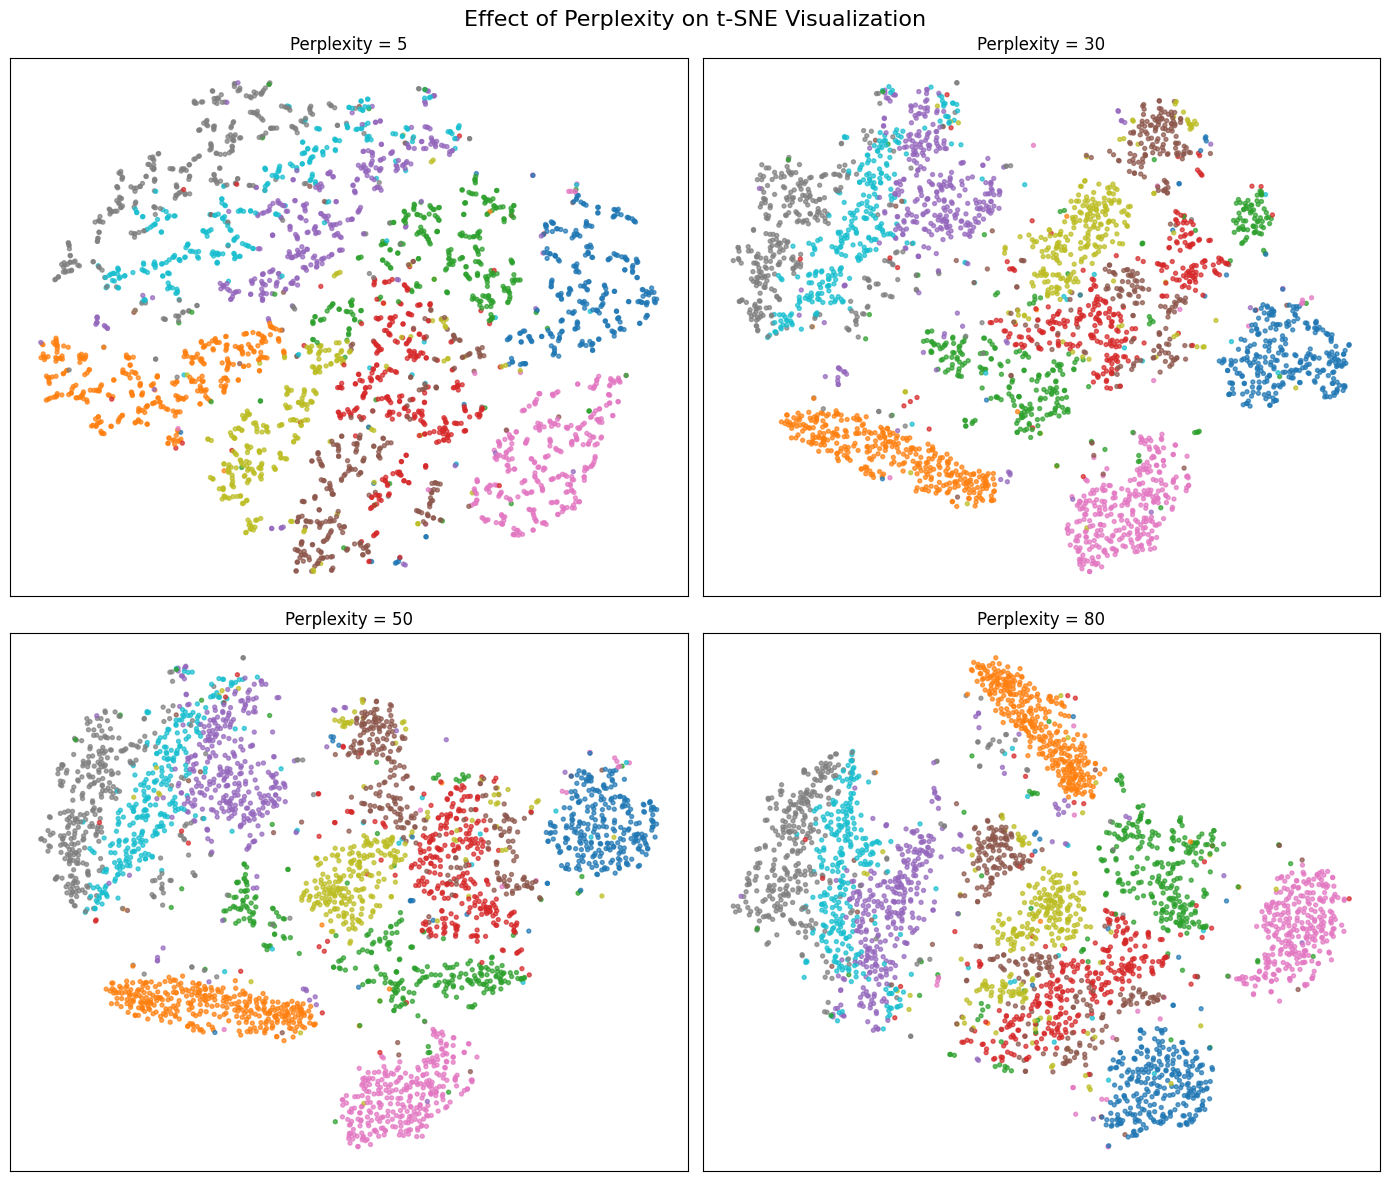

In [7]:
# Cell 10: Perplexity 对比实验
perplexities = [5, 30, 50, 80]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, perp in zip(axes.ravel(), perplexities):
    print(f"正在计算 Perplexity = {perp} ...")
    tsne_temp = TSNE(n_components=2, perplexity=perp, learning_rate=200,
                     random_state=42, max_iter=1000)   # ← 这里改成了 max_iter
    X_tsne_temp = tsne_temp.fit_transform(X_pca)
    
    ax.scatter(X_tsne_temp[:, 0], X_tsne_temp[:, 1], c=y, cmap='tab10', s=8, alpha=0.7)
    ax.set_title(f'Perplexity = {perp}', fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(alpha=0.3)

plt.suptitle('Effect of Perplexity on t-SNE Visualization', fontsize=16)
plt.tight_layout()
plt.show()

### 实验 2：t-SNE 与 PCA 的直接对比
将 PCA 直接降到 2 维，与 t-SNE 结果放在一起，直观感受非线性降维的优势。

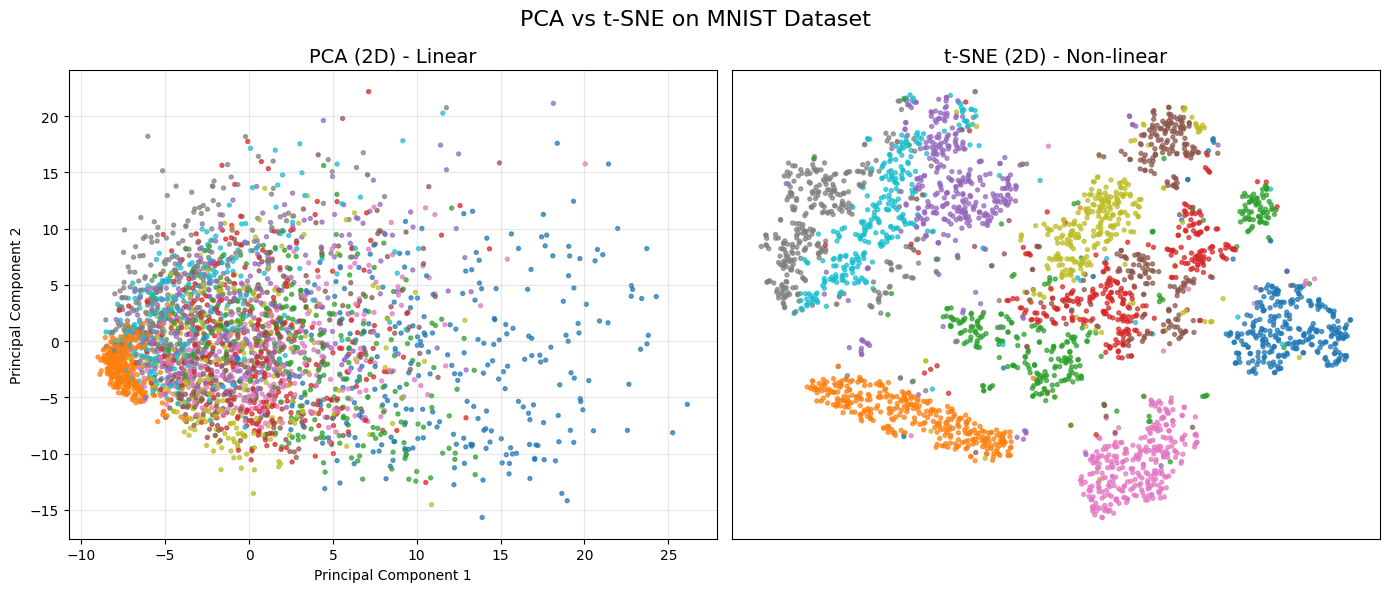

In [8]:
# Cell 12: PCA vs t-SNE 对比图
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：PCA
axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab10', s=8, alpha=0.7)
axes[0].set_title('PCA (2D) - Linear', fontsize=14)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(alpha=0.3)

# 右图：t-SNE
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=8, alpha=0.7)
axes[1].set_title('t-SNE (2D) - Non-linear', fontsize=14)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].grid(alpha=0.3)

plt.suptitle('PCA vs t-SNE on MNIST Dataset', fontsize=16)
plt.tight_layout()
plt.show()

## 5. 练习与思考

可加深理解：
1. **调整学习率**：尝试 `learning_rate = [10, 50, 500]`，观察结果是否出现“拥挤球”或“碎片化”现象，记录最优值。
2. **更换数据集**：在 `sklearn.datasets.load_digits()` 或 `load_iris()` 上重复本实验，对比不同数据量下的表现。
3. **三维可视化**：设置 `TSNE(n_components=3)`，并使用 `mpl_toolkits.mplot3d` 绘制交互式三维散点图。

## 6. 总结与参考

### 核心总结

| 要点 | 说明 |
|------|------|
| **定位** | 非线性降维，专用于高维数据可视化 |
| **核心机制** | 高维用高斯分布、低维用 t 分布，最小化 KL 散度 |
| **关键参数** | perplexity（5-50）、learning_rate（100-1000）、n_iter（>=500） |
| **优势** | 卓越的局部结构保留能力，聚类可视化效果极佳 |
| **局限** | 计算慢（O(N²)）、随机性大、无法处理新数据、不保留全局距离 |

### 参考来源

1. [t-SNE原理与推导 - CSDN](https://blog.csdn.net/scott198510/article/details/76099700)
2. [t-SNE 简介 - 博客园](https://www.cnblogs.com/dingxingdi/p/19469303)
3. [深入解析t-SNE：从理论到实践的降维可视化指南 - CSDN](https://blog.csdn.net/m0_74882984/article/details/144041227)
4. Maaten, L. van der, & Hinton, G. (2008). Visualizing Data using t-SNE. *Journal of Machine Learning Research*, 9, 2579-2605.

